# **Database construction & cleaning**

In [ ]:
import netCDF4 as nc
import pandas as pd
import numpy as np

file_path = "Rx5day.nc"
ds = nc.Dataset(file_path, 'r')

#for var in ds.variables:
#    print(f"  - Variable: {var}")
#    print(f"    Dimensions: {ds.variables[var].dimensions}")
#    print(f"    Shape: {ds.variables[var].shape}")

rx5day = ds.variables['rx5dayETCCDI'][:]  
#print(f"Valeurs manquantes : {np.isnan(rx5day).sum()}")

#conversion des longitudes nécessaire
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

lon_adj = np.where(lon > 180, lon - 360, lon)
sort_idx = np.argsort(lon_adj)
lon_sorted = lon_adj[sort_idx]
rx5day_sorted = rx5day[:, :, sort_idx]  
rx5day=rx5day_sorted
lon=lon_sorted
#print(f"lat.shape = {lat.shape}, lon.shape = {lon.shape}")
#print(f"rx5day.shape = {rx5day.shape} (doit être (time, lat.shape[0], lon.shape[0]))")
#print(f"lat.shape[0] == len(lat) : {lat.shape[0] == len(lat)}")
#print(f"lon.shape[0] == len(lon) : {lon.shape[0] == len(lon)}")
#print(f"rx5day.shape[1] == lat.shape[0] : {rx5day.shape[1] == lat.shape[0]}")
#print(f"rx5day.shape[2] == lon.shape[0] : {rx5day.shape[2] == lon.shape[0]}")   
#Normalement, les pixels sont organisés en une grille régulière, donc les dimensions de lat et lon devraient correspondre à celles de rx5day.

time = ds.variables['time'][:]
#time_bounds=ds.variables['time_bounds'][:] # -> nombre de jour entre chaque date, bornes temporelles  
t_units = ds.variables['time'].units
t_calendar = ds.variables['time'].calendar if hasattr(ds.variables['time'], 'calendar') else 'standard'
#print (t_units, "\n",t_calendar)
dates_python = nc.num2date(time, units=t_units, calendar=t_calendar)#convertir les dates en format datetime
dates = [pd.Timestamp(f"{d.year}-{d.month:02d}-{d.day:02d}") for d in dates_python]
#print (dates[:5])

df = pd.DataFrame(
    rx5day.reshape(len(dates), -1), #on passe de 3 dimensions (time, lat, lon) à 2 dimensions (time, pixels)
    index=dates,
    columns=[f"lat_{lat[i]:.2f}_lon_{lon[j]:.2f}" for i in range(len(lat)) for j in range(len(lon))]
)
array = df.values.reshape(len(dates), len(lat), len(lon), 1)
#print(df.head())
#print("\nForme de l'array 4D :", array_4d.shape)
ds.close()

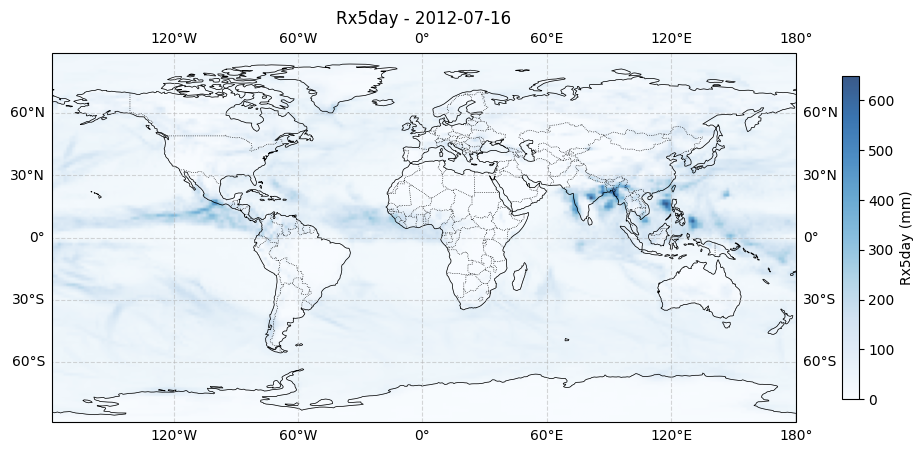

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import num2date

#rng = np.random.default_rng(seed=42)
#idx = rng.integers(0, len(dates)) #at random
idx=1950
the_date = dates[idx]
data_img = array[idx, :, :, 0]  

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.imshow(data_img, extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower', cmap='Blues', alpha=0.8,
               transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.show()

In [4]:
#print(f"Longitudes min et max : {lon.min():.1f}, {lon.max():.1f}")
#lon_centered = np.where(lon > 180, lon - 360, lon)
#print(lon_centered)
lat_min, lat_max = 41.0, 52.0   
lon_min, lon_max = -5.0, 9.0
lat_indices = np.where((lat >= lat_min) & (lat <= lat_max))[0]
#lon_indices = np.where((lon_centered >= lon_min) & (lon_centered <= lon_max))[0]
lon_indices = np.where((lon >= lon_min) & (lon <= lon_max))[0]
#print(lon_indices)

lat_france = lat[lat_indices]
lon_france = lon[lon_indices]
print(lat_france, "\n", lon_france)

array_fr= array[:, lat_indices, :, :][:, :, lon_indices, :]  # (time, len(lat_indices), len(lon_indices), 1)
print(array_fr.shape)
#8x9, 1980 observations temporelles, 1 variable (Rx5day) -> (1980, 7, 9, 1)



[41.32257587 42.72333486 44.12409297 45.5248501  46.92560615 48.32636102
 49.72711456 51.12786664] 
 [-4.21875 -2.8125  -1.40625  0.       1.40625  2.8125   4.21875  5.625
  7.03125  8.4375 ]
(1980, 8, 10, 1)


#Visu

idx=1950
the_date = dates[idx]
img_base = array_fr[idx, :, :, 0]  
m = img_base.mean()
std = img_base.std()
img_norma= (img_base - m) / std

img_min = img_base.min()
img_max = img_base.max()
img_minmax = (img_base - img_min) / (img_max - img_min)

for img in [img_base, img_norma, img_minmax]:
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes(projection=ccrs.PlateCarree())

    #Ajuster les limites de l'image pour correspondre à la région de la France
    im = ax.imshow(img, extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],
                origin='lower', cmap='Blues', alpha=0.8,
                transform=ccrs.PlateCarree())
    #ax.set_extent([lon_france.min(), lon_france.max(),                lat_france.min(), lat_france.max()],               crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

    plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
    ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")} - {"Base" if img is img_base else "Normalisée" if img is img_norma else "Min-Max"}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

    plt.show()


# **Analyse exploratoire des données**

C:\Users\alexd\AppData\Local\Temp\ipykernel_22300\1414889581.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_month, labels=range(1,13), patch_artist=True,


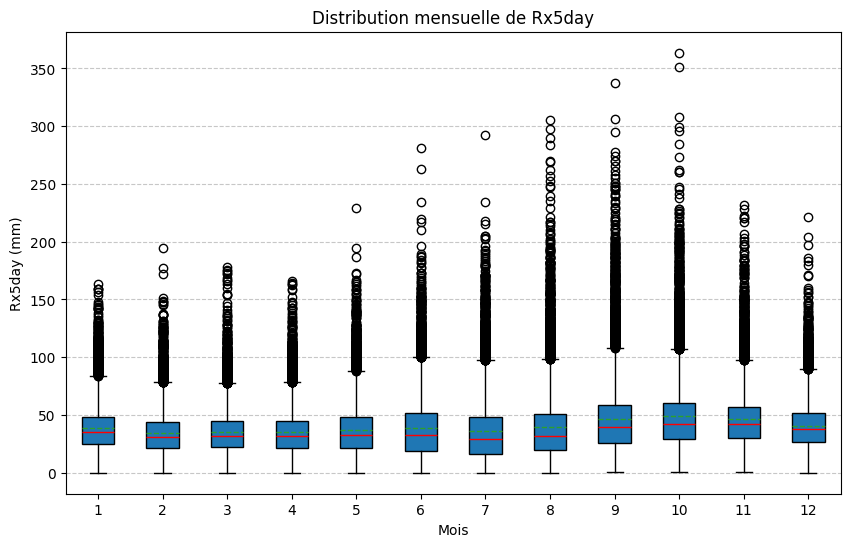

In [5]:
data = array_fr.squeeze()
labels_data= np.array(dates)

months = np.array([d.month for d in dates])
years  = np.array([d.year  for d in dates])

data_by_month = []
for m in range(1, 13):
    mask = (months == m)

    values = data[mask].ravel() 
    data_by_month.append(values)

plt.figure(figsize=(10, 6))
plt.boxplot(data_by_month, labels=range(1,13), patch_artist=True,
            showmeans=True, meanline=True, medianprops={'color':'red'})
plt.xlabel('Mois')
plt.ylabel('Rx5day (mm)')
plt.title('Distribution mensuelle de Rx5day')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **(GAN))**

In [ ]:
from fonction_en_plus.WGANGP import WGANGP
from fonction_en_plus.DCGAN import DCGAN 
from fonction_en_plus.ImagesCallback_V2 import ImagesCallback_V2
import os
import keras
from keras import layers
from skimage import io
import sys
import fidle
from tensorflow.keras.callbacks import TensorBoard
import torch
from torch.distributions.normal import Normal

os.environ['KERAS_BACKEND'] = 'tensorflow'
latent_dim=128 #256 ?
n_critic= 8
epochs= 5
batch_size = 4

seed=42
fit_verbosity = 1 #Plus agréable
#latent_dim = 12 # et si on gonfle la taille ? 
  #4-6: équilibré// 6-12: plus de capacité, mais risque de surapprentissage
#?? faut il +/- de dimension en fonction de la taille ?? Faut il tester plusieurs dimensions ??
#2 if we want to visualize the latent space (harder compression though)

loss_weights  = [1,.06]

#useful ?
#x_data = x_data/255 # marche car blanc ou noir
#x_data = x_data.reshape(-1,28,28,1)# reshape 1D-> 2D
#np.random.shuffle(x_data)

In [66]:
oups_data = array_fr
#mean = oups_data.mean()
#std = oups_data.std()
#x_data= (oups_data - mean) / std
#pref ?
x_min = oups_data.min()
x_max = oups_data.max()
x_data = (oups_data - x_min) / (x_max - x_min)

#print(x_data.min(), x_data.max())

print(min(labels_data), max(labels_data), len (labels_data))

1850-01-16 00:00:00 2014-12-16 00:00:00 1980


**Discriminator**

In [67]:
#leakyRelu pour améliorer cv opti
#strides 2 au lieu de maxpooling
#  sigmoid to get output in [0,1] range (because of the normalization of the input images)
# pk préciser pente LeakyRelu ?
# Stride = 2 to downsample
# padding = "same" to keep the output size the same as input size
# (except for the last layer)
#augmente kernel_size-> picture + grande ?

#?? est-ce qu'il vauydrait mieux une autre architecture ? Trop petit ??


*DCGAN*

In [68]:
inputs= keras.Input(shape=(8, 10, 1)) #taille image en entrée
x=layers.Conv2D(16, kernel_size=3, strides=1, padding="same")(inputs)
x=layers.LeakyReLU(alpha=0.2)(x)
x= layers.Conv2D(32, 3, strides=1, padding="same")(x)
x= layers.LeakyReLU(alpha=0.2)(x)

x         = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x) 
z       = layers.Dense(1, activation="sigmoid")(x) 

discriminator = keras.Model(inputs, z, name="discriminator")
#discriminator.summary()

#Comparaison
#inputs  = keras.Input(shape=(28, 28, 1))
#x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)

c:\Users\alexd\Documents\GenAI\TP\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


*WGANGP*

In [69]:
inputs    = keras.Input(shape=(8, 10, 1)) #taille image en entrée
x = layers.Conv2D(16, kernel_size=3, strides=1, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x         = layers.Conv2D(32, 3, strides=1, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)

x         = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x) 
z       = layers.Dense(1)(x) 

discriminator_wg = keras.Model(inputs, z, name="discriminator_wg")
#discriminator.summary()

#Comparaison
#inputs  = keras.Input(shape=(28, 28, 1))
#x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)

**Generator** : Same DCGAN & WGANGP

In [70]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(4 * 5 * 16)(inputs) 
x       = layers.Reshape((4, 5, 16))(x)
x       = layers.UpSampling2D()(x)
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation='relu')(x)
x       = layers.UpSampling2D()(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)

generator = keras.Model(inputs, outputs, name="generator")
#generator.summary()

#Comparaison
#x       = layers.Dense(7 * 7 * 64)(inputs)
#x       = layers.Reshape((7, 7, 64))(x)
#x       = layers.UpSampling2D()(x)
#x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
#x       = layers.UpSampling2D()(x)
#x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
#outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)

In [71]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

gan_wg = WGANGP(discriminator=discriminator_wg, generator=generator, latent_dim=latent_dim, n_critic=n_critic)

Fidle WGANGP is ready :-)  latent dim = 32


In [72]:
gan.compile(
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001),
    loss_function           = keras.losses.BinaryCrossentropy(),
)

gan_wg.compile(
#     discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
#     generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001)
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
)

In [73]:
run_dir = '.'
imagesCallback_V2 = ImagesCallback_V2(num_img=3, latent_dim=latent_dim, run_dir=f'{run_dir}/images')


In [74]:
history = gan.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback_V2], 
                   verbose=fit_verbosity )

Epoch 1/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - d_loss: 0.6365 - g_loss: 0.8519
Epoch 2/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - d_loss: 0.6343 - g_loss: 0.8040
Epoch 3/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - d_loss: 0.6929 - g_loss: 0.7022
Epoch 4/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - d_loss: 0.7060 - g_loss: 0.6792
Epoch 5/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - d_loss: 0.6963 - g_loss: 0.6899


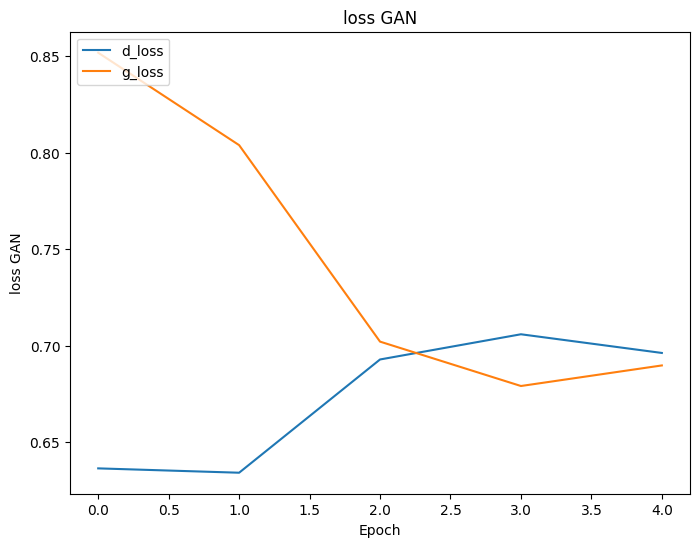

In [75]:
fidle.scrawler.history(history,  plot={'loss GAN':['d_loss','g_loss']})

#d_loss (Perte du discriminateur) : Doit converger vers une valeur négative 
# (pour WGAN) ou osciller autour de 0.5 (pour GAN classique). 
# Si elle tombe à 0 ou devient trop grande, le modèle diverge.
#g_loss (Perte du générateur) : Doit diminuer.

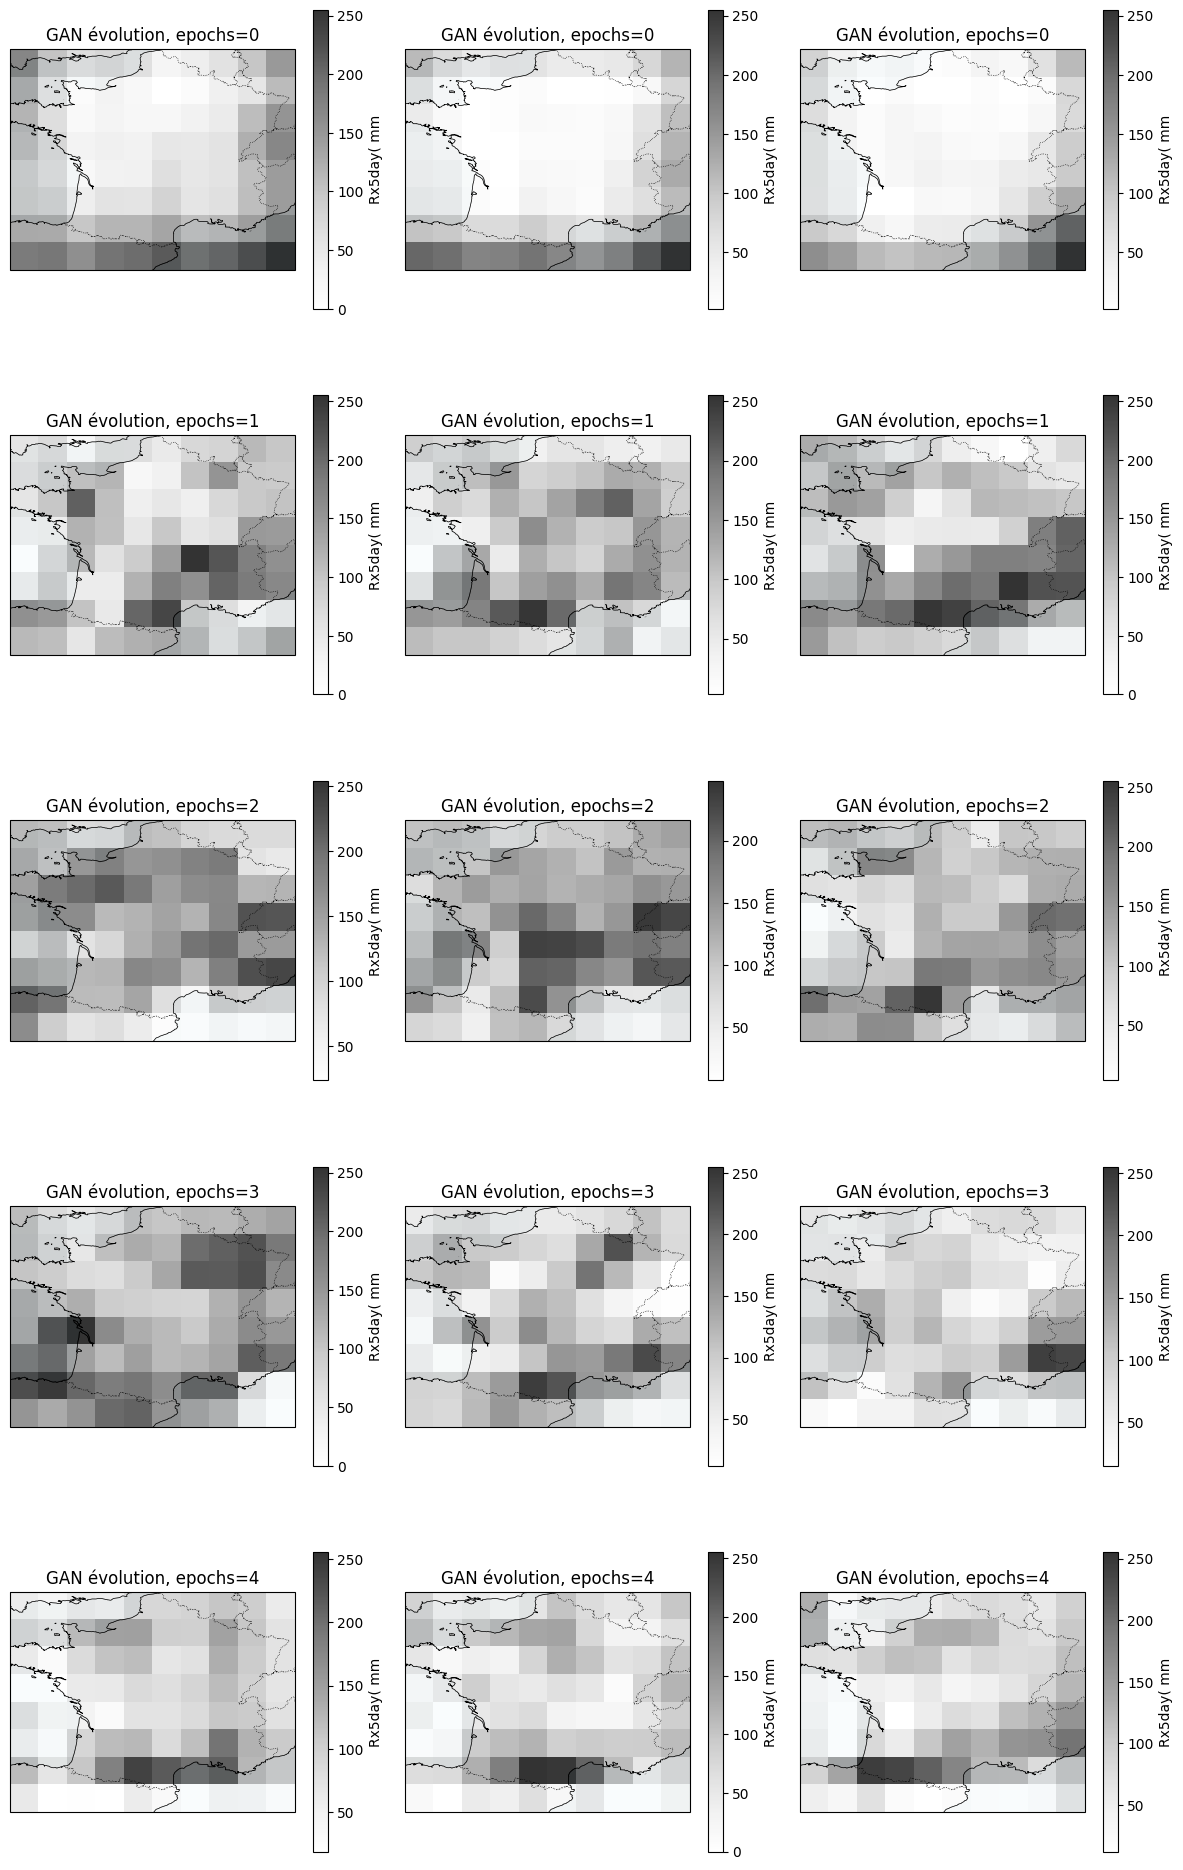

In [76]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(12):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      


fig, axes = plt.subplots(epochs, 3, figsize=(4*3, epochs*4), subplot_kw={'projection': ccrs.PlateCarree()})
for j in range (epochs):
    for i in range(3):
        idx=j*3+i
        ax=axes[j,i]
        image = images[idx]

        im = ax.imshow(image,extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],origin='lower', cmap='Greys', 
                       alpha=0.8,transform=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
        ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
        #ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

        ax.set_title(f"GAN évolution, epochs={j}")

        plt.colorbar(im, ax=ax, label='Rx5day( mm', shrink=0.7)

plt.tight_layout()
plt.show()


In [77]:
history_wg = gan_wg.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback_V2], 
                   verbose=fit_verbosity )

Epoch 1/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - d_loss: 0.2775 - g_loss: 0.1273
Epoch 2/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - d_loss: -0.0467 - g_loss: 1.2917
Epoch 3/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - d_loss: -0.0269 - g_loss: 1.2168
Epoch 4/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - d_loss: -0.0289 - g_loss: 1.1131
Epoch 5/5
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - d_loss: -0.0049 - g_loss: -0.4291


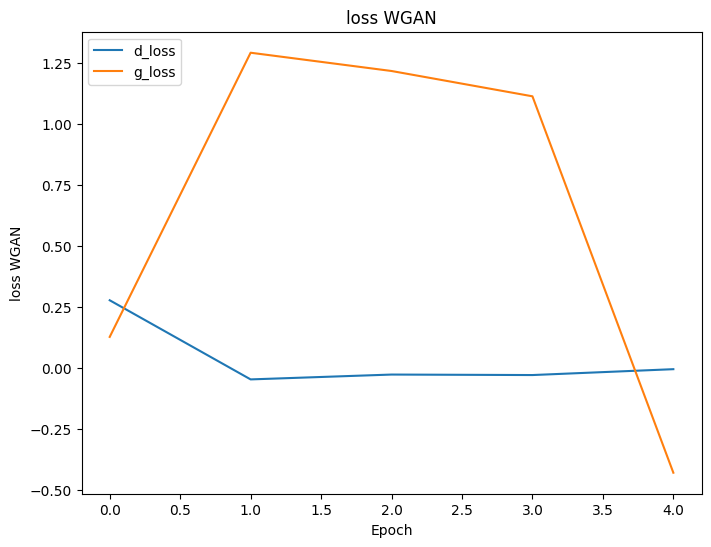

In [78]:
fidle.scrawler.history(history_wg,  plot={'loss WGAN':['d_loss','g_loss']})
#d_loss (Perte du discriminateur) : Doit converger vers une valeur négative 
# (pour WGAN) ou osciller autour de 0.5 (pour GAN classique). 
# Si elle tombe à 0 ou devient trop grande, le modèle diverge.
#g_loss (Perte du générateur) : Doit diminuer.

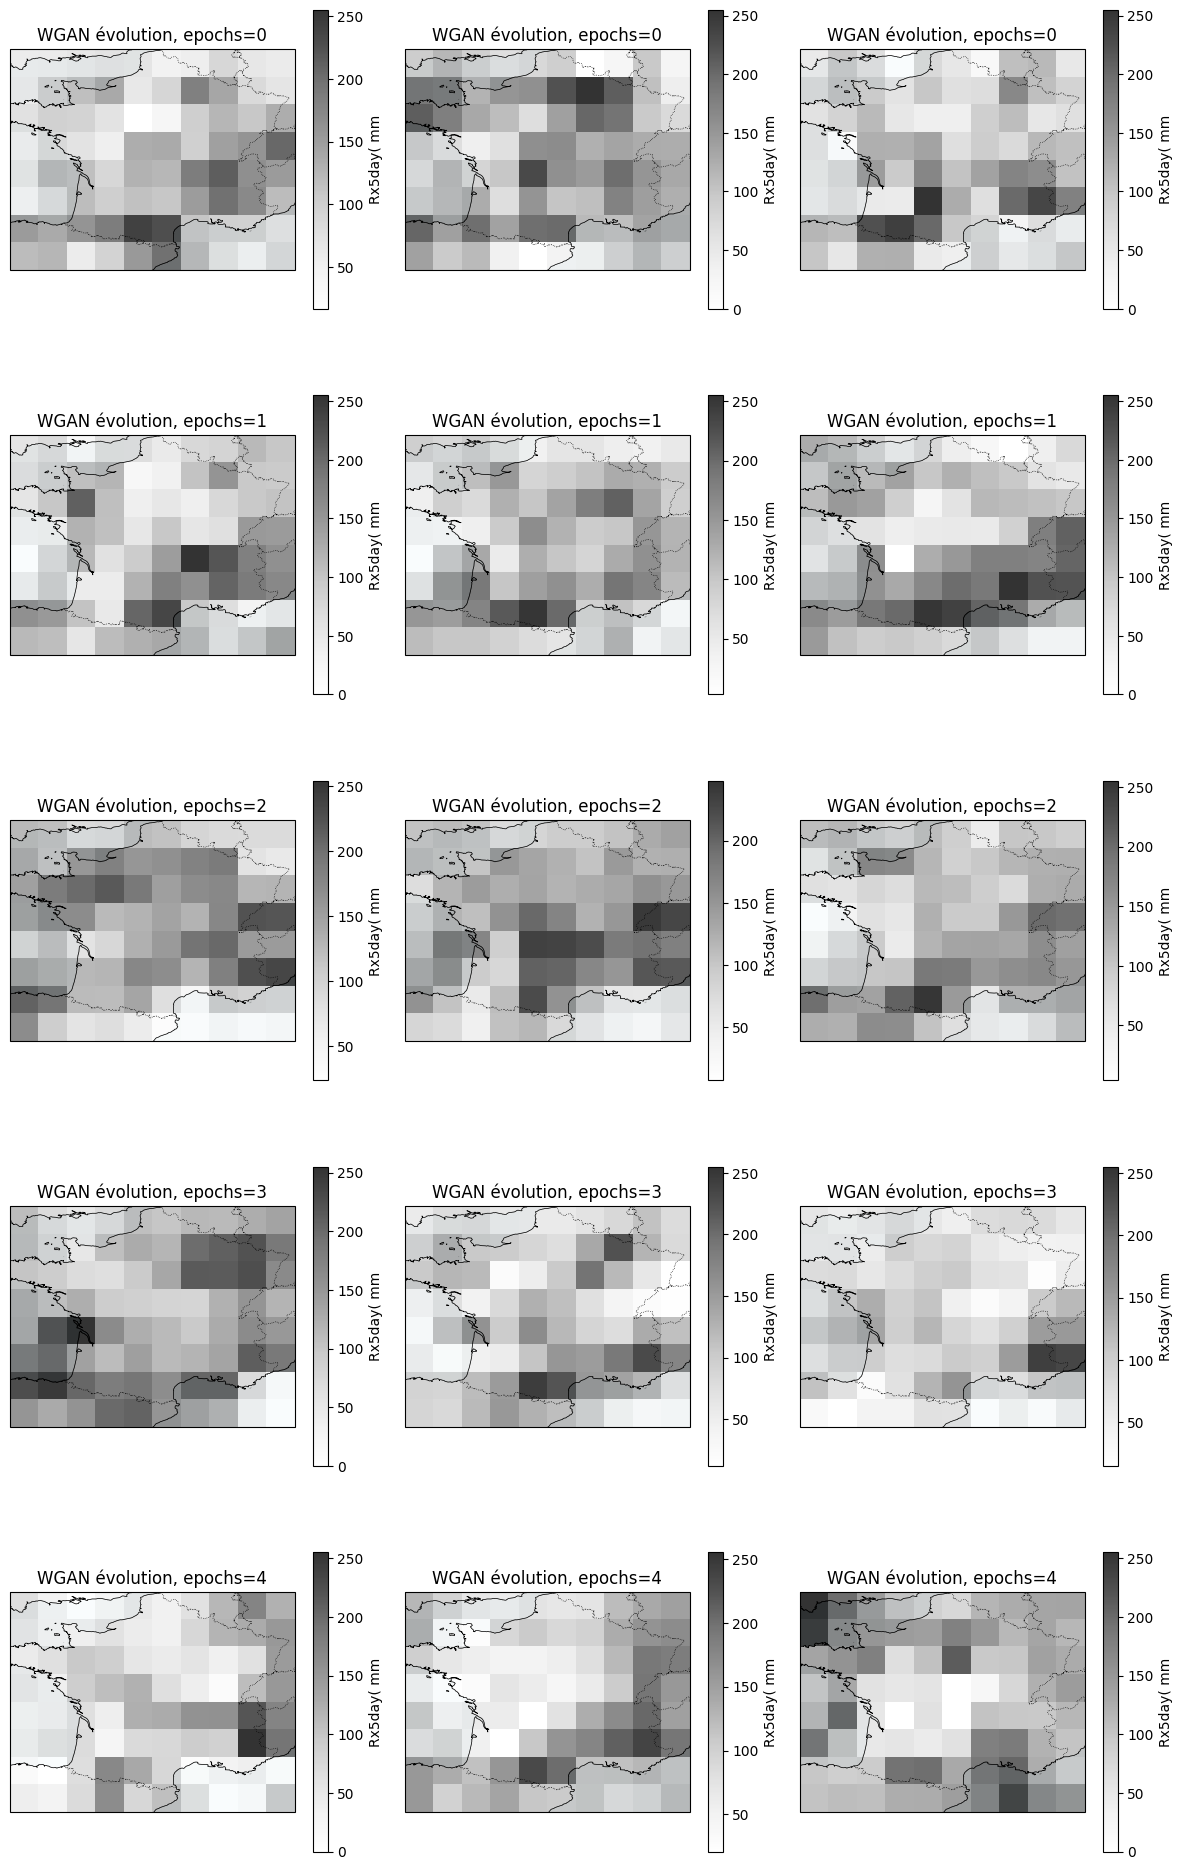

In [79]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(12):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      


fig, axes = plt.subplots(epochs, 3, figsize=(4*3, epochs*4), subplot_kw={'projection': ccrs.PlateCarree()})
for j in range (epochs):
    for i in range(3):
        idx=j*3+i
        ax=axes[j,i]
        image = images[idx]

        im = ax.imshow(image,extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],origin='lower', cmap='Greys', 
                       alpha=0.8,transform=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
        ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
        #ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

        ax.set_title(f"WGAN évolution, epochs={j}")

        plt.colorbar(im, ax=ax, label='Rx5day( mm', shrink=0.7)

plt.tight_layout()
plt.show()


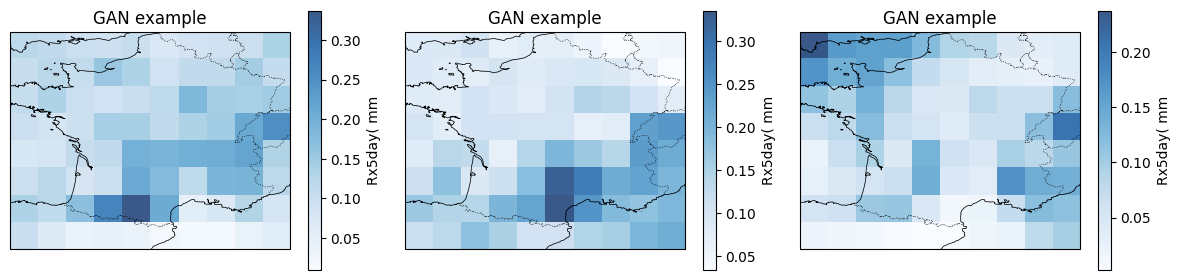

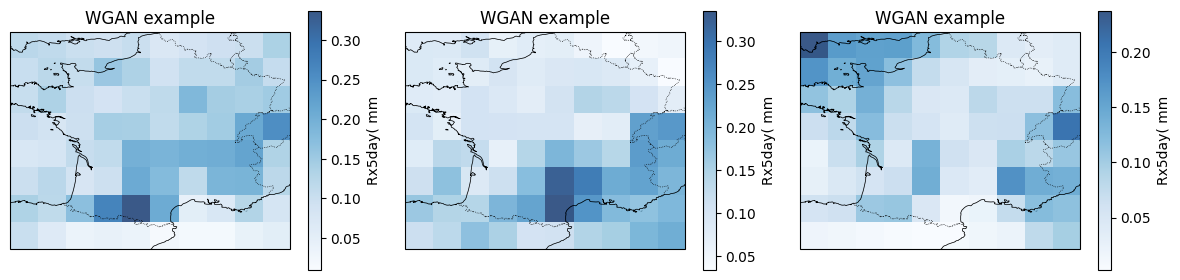

In [80]:
nb_images = 3
z_sample = np.random.normal(size=(nb_images,latent_dim))
imgs = gan.predict(z_sample, verbose=0)
imgs_wg = gan_wg.predict(z_sample, verbose=0)

fig, axes = plt.subplots(1, nb_images, figsize=(nb_images*4, 4), subplot_kw={'projection': ccrs.PlateCarree()})

if nb_images == 1:
    axes = [axes]
for i,ax in enumerate(axes):
    image = imgs[i, :, :, 0]

    im = ax.imshow(image,extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],origin='lower', cmap='Blues', alpha=0.8,transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,facecolor='white', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
    #ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

    ax.set_title(f"GAN example")

    plt.colorbar(im, ax=ax, label='Rx5day( mm', shrink=0.7)

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, nb_images, figsize=(nb_images*4, 4), subplot_kw={'projection': ccrs.PlateCarree()})

if nb_images == 1:
    axes2 = [axes2]
for i,ax in enumerate(axes2):
    image = imgs_wg[i, :, :, 0]

    im = ax.imshow(image,extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],origin='lower', cmap='Blues', alpha=0.8,transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,facecolor='white', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
    #ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

    ax.set_title(f"WGAN example")

    plt.colorbar(im, ax=ax, label='Rx5day( mm', shrink=0.7)

plt.tight_layout()
plt.show()


# TUNING GAN

In [ ]:
import itertools
import pandas as pd
import os

search_space = {
    'model_type': ['DCGAN', 'WGANGP'],
    'latent_dim': [64, 128],        
    'learning_rate': [0.0001, 0.0002],
    'batch_size': [4, 8]           
}

keys, values = zip(*search_space.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]


In [ ]:

results = []
os.makedirs('./tuning_gan', exist_ok=True)

for i, cfg in enumerate(configs):
    print(f"\n>>> RUN {i+1}/{len(configs)}: {cfg}")

    inputs_g = keras.Input(shape=(cfg['latent_dim'],))
    x = layers.Dense(4 * 5 * 16)(inputs_g)
    x = layers.Reshape((4, 5, 16))(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation='relu')(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation='relu')(x)
    outputs_g = layers.Conv2D(1, kernel_size=5, padding="same", activation="sigmoid")(x)
    curr_gen = keras.Model(inputs_g, outputs_g)

    if cfg['model_type'] == 'DCGAN':
        model = DCGAN(discriminator=discriminator, generator=curr_gen, latent_dim=cfg['latent_dim'])
        model.compile(
            discriminator_optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate'], beta_1=0.5),
            generator_optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate'], beta_1=0.5),
            loss_function=keras.losses.BinaryCrossentropy()
        )
    else:
        model = WGANGP(discriminator=discriminator_wg, generator=curr_gen, latent_dim=cfg['latent_dim'], n_critic=8)
        model.compile(
            discriminator_optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate'], beta_1=0.5, beta_2=0.9),
            generator_optimizer=keras.optimizers.Adam(learning_rate=cfg['learning_rate'], beta_1=0.5, beta_2=0.9)
        )

    run_name = f"{cfg['model_type']}_L{cfg['latent_dim']}_B{cfg['batch_size']}_LR{cfg['learning_rate']}"
    cb = ImagesCallback_V2(num_img=3, latent_dim=cfg['latent_dim'], run_dir=f'./tuning_gan/{run_name}')

    history = model.fit(
        x_data.astype('float32'), 
        epochs=10, 
        batch_size=cfg['batch_size'], 
        callbacks=[cb], 
        verbose=0
    )

    results.append({**cfg, 
                    'd_loss': history.history['d_loss'][-1], 
                    'g_loss': history.history['g_loss'][-1]})

    pd.DataFrame(results).to_csv("./tuning_gan/gan_summary.csv", index=False)

print("\nTuning fini")


>>> RUN 1/16: {'model_type': 'DCGAN', 'latent_dim': 64, 'learning_rate': 0.0001, 'batch_size': 4}

>>> RUN 2/16: {'model_type': 'DCGAN', 'latent_dim': 64, 'learning_rate': 0.0001, 'batch_size': 8}

>>> RUN 3/16: {'model_type': 'DCGAN', 'latent_dim': 64, 'learning_rate': 0.0002, 'batch_size': 4}

>>> RUN 4/16: {'model_type': 'DCGAN', 'latent_dim': 64, 'learning_rate': 0.0002, 'batch_size': 8}

>>> RUN 5/16: {'model_type': 'DCGAN', 'latent_dim': 128, 'learning_rate': 0.0001, 'batch_size': 4}

>>> RUN 6/16: {'model_type': 'DCGAN', 'latent_dim': 128, 'learning_rate': 0.0001, 'batch_size': 8}

>>> RUN 7/16: {'model_type': 'DCGAN', 'latent_dim': 128, 'learning_rate': 0.0002, 'batch_size': 4}

>>> RUN 8/16: {'model_type': 'DCGAN', 'latent_dim': 128, 'learning_rate': 0.0002, 'batch_size': 8}

>>> RUN 9/16: {'model_type': 'WGANGP', 'latent_dim': 64, 'learning_rate': 0.0001, 'batch_size': 4}
Fidle WGANGP is ready :-)  latent dim = 64

>>> RUN 10/16: {'model_type': 'WGANGP', 'latent_dim': 64, 'l

In [2]:
import pandas as pd

gan_summary = pd.read_csv("tuning_gan/gan_summary.csv")
gan_summary

,model_type,latent_dim,learning_rate,batch_size,d_loss,g_loss
0,DCGAN,64,0.0001,4,0.694855,0.691179
1,DCGAN,64,0.0001,8,0.696477,0.692380
2,DCGAN,64,0.0002,4,0.695259,0.692713
3,DCGAN,64,0.0002,8,0.695333,0.694658
4,DCGAN,128,0.0001,4,0.696637,0.693318
5,DCGAN,128,0.0001,8,0.687287,0.707759
6,DCGAN,128,0.0002,4,0.701291,0.690307
7,DCGAN,128,0.0002,8,0.709690,0.681820
8,WGANGP,64,0.0001,4,0.000316,-0.276463
9,WGANGP,64,0.0001,8,0.004778,-0.042435


Loss: Constante à 0.693 ($-\ln 0.5$). Blocage

WGAN pour sortir du blocage

Batch size  de 8 semble etre equilibrée

In [ ]:
optimal_search = {
    'latent_dim': [32, 128],
    'n_critic': [5, 10],
    'lr_d': [0.0004], 
    'lr_g': [0.0001],
    'beta_1': [0.0, 0.5] 
}

keys, values = zip(*optimal_search.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]
results = []

for i, cfg in enumerate(configs):
    print(f"\n>>> EXPERIMENT {i+1}/{len(configs)} | {cfg}")

    # Generator
    in_g = keras.Input(shape=(cfg['latent_dim'],))
    x = layers.Dense(4 * 5 * 128)(in_g) 
    x = layers.Reshape((4, 5, 128))(x)
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Conv2D(64, 3, padding="same", activation='relu')(x)
    out_g = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)
    curr_gen = keras.Model(in_g, out_g)

    # Discriminator
    in_d = keras.Input(shape=(8, 10, 1))
    x = layers.Conv2D(64, 3, strides=1, padding="same")(in_d)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    out_d = layers.Dense(1)(x)
    curr_disc = keras.Model(in_d, out_d)

    model = WGANGP(discriminator=curr_disc, generator=curr_gen, 
                   latent_dim=cfg['latent_dim'], n_critic=cfg['n_critic'])
    
    model.compile(
        discriminator_optimizer=keras.optimizers.Adam(learning_rate=cfg['lr_d'], beta_1=cfg['beta_1'], beta_2=0.9),
        generator_optimizer=keras.optimizers.Adam(learning_rate=cfg['lr_g'], beta_1=cfg['beta_1'], beta_2=0.9)
    )

    run_id = f"OPT_L{cfg['latent_dim']}_NC{cfg['n_critic']}_B{cfg['beta_1']}"
    cb = ImagesCallback_V2(num_img=3, latent_dim=cfg['latent_dim'], run_dir=f'./opt_tuning/{run_id}')

    history = model.fit(x_data.astype('float32'), 
                        epochs=10, 
                        batch_size=8, 
                        callbacks=[cb], 
                        verbose=0)

    results.append({**cfg, 'd_loss': history.history['d_loss'][-1], 'g_loss': history.history['g_loss'][-1]})


>>> EXPERIMENT 1/8 | {'latent_dim': 32, 'n_critic': 5, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.0}
Fidle WGANGP is ready :-)  latent dim = 32

>>> EXPERIMENT 2/8 | {'latent_dim': 32, 'n_critic': 5, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.5}
Fidle WGANGP is ready :-)  latent dim = 32

>>> EXPERIMENT 3/8 | {'latent_dim': 32, 'n_critic': 10, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.0}
Fidle WGANGP is ready :-)  latent dim = 32

>>> EXPERIMENT 4/8 | {'latent_dim': 32, 'n_critic': 10, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.5}
Fidle WGANGP is ready :-)  latent dim = 32

>>> EXPERIMENT 5/8 | {'latent_dim': 128, 'n_critic': 5, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.0}
Fidle WGANGP is ready :-)  latent dim = 128

>>> EXPERIMENT 6/8 | {'latent_dim': 128, 'n_critic': 5, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.5}
Fidle WGANGP is ready :-)  latent dim = 128

>>> EXPERIMENT 7/8 | {'latent_dim': 128, 'n_critic': 10, 'lr_d': 0.0004, 'lr_g': 0.0001, 'beta_1': 0.0}
Fidle WGANGP 

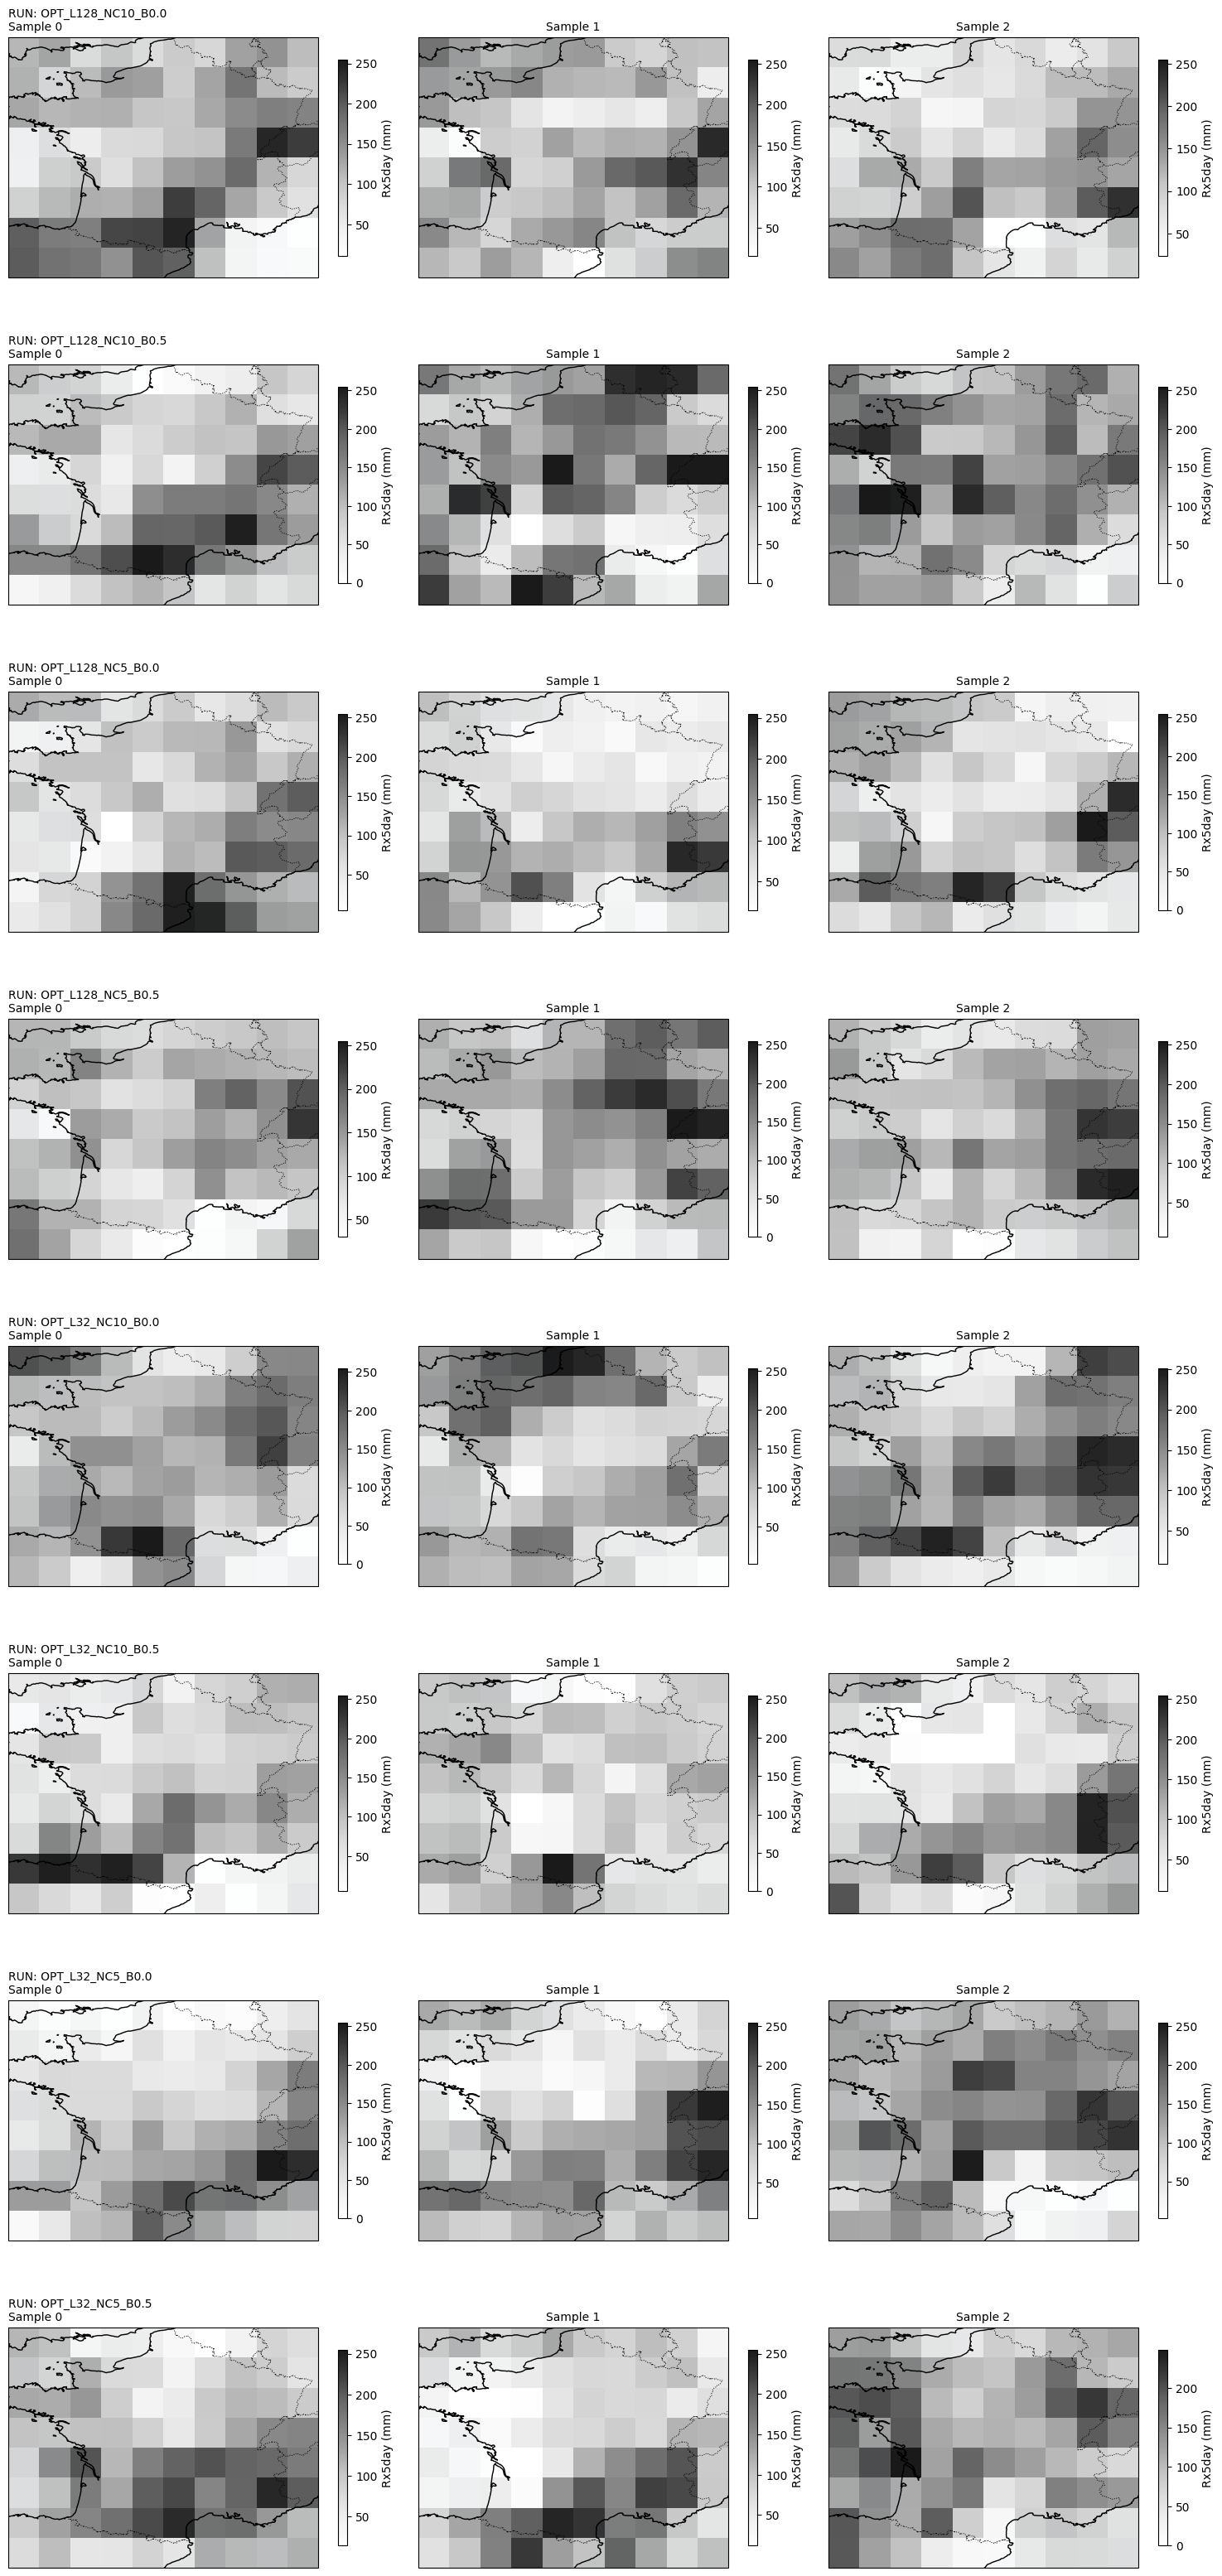

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
from skimage import io

def display_tuning_carto(base_dir='./opt_tuning', num_images=3):

    runs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
    
    if not runs:
        return print("Pas de run", base_dir)

    extent = [lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()]

    n_runs = len(runs)
    fig, axes = plt.subplots(n_runs, num_images, figsize=(num_images * 5, n_runs * 4), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    if n_runs == 1: axes = [axes]

    for i, run in enumerate(runs):
        img_paths = sorted(glob.glob(os.path.join(base_dir, run, "*.jpg")))
        selected_imgs = img_paths[-num_images:]
        
        for j in range(num_images):
            ax = axes[i, j]
            
            if j < len(selected_imgs):
                image = io.imread(selected_imgs[j])

                im = ax.imshow(image, extent=extent, origin='lower', 
                               cmap='Greys', alpha=0.9, transform=ccrs.PlateCarree())

                ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='black', linewidth=0.8)
                ax.add_feature(cfeature.COASTLINE, linewidth=1)
                ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
                ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

                if j == 0:
                    ax.set_title(f"RUN: {run}\nSample {j}", loc='left', fontsize=10)
                else:
                    ax.set_title(f"Sample {j}", fontsize=10)

                plt.colorbar(im, ax=ax, label='Rx5day (mm)', shrink=0.6, pad=0.05)
            else:
                ax.set_visible(False)

    plt.tight_layout()
    plt.show()

display_tuning_carto()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)


df_results['d_loss'] = df_results['d_loss'].round(4)
df_results['g_loss'] = df_results['g_loss'].round(4)

df_results['ratio_G_D'] = (df_results['g_loss'] / df_results['d_loss']).abs().round(2)

df_table = df_results.sort_values(by='g_loss', ascending=True)

display(df_table[['latent_dim', 'n_critic', 'beta_1', 'lr_d', 'lr_g', 'd_loss', 'g_loss', 'ratio_G_D']])

--- RÉSULTATS DU TUNING OPTIMAL (Rx5day 8x10) ---


,latent_dim,n_critic,beta_1,lr_d,lr_g,d_loss,g_loss,ratio_G_D
1,32,5,0.5,0.0004,0.0001,-0.0193,-0.4348,22.53
6,128,10,0.0,0.0004,0.0001,-0.0414,-0.2907,7.02
7,128,10,0.5,0.0004,0.0001,-0.0531,-0.1644,3.10
0,32,5,0.0,0.0004,0.0001,-0.0121,-0.1501,12.40
2,32,10,0.0,0.0004,0.0001,-0.0376,-0.1404,3.73
3,32,10,0.5,0.0004,0.0001,-0.0517,-0.1144,2.21
4,128,5,0.0,0.0004,0.0001,-0.0140,0.4818,34.41
5,128,5,0.5,0.0004,0.0001,-0.0240,0.6084,25.35


Interprétation du tuning

Pour latent dim 128 on voit que la g loss final est parfois positive et la ratio est très élevée, ce qui montre uen certaine instabilité.
On observe dans les images plus souvent des images bruités pour les cofnigurations avec 128 en dimension latente

Pour le n critic: l'augmenter permet de mieux stabiliser le ratio.

Pour le TTUR avec l'optimisateur Adam on remarque que le choix de 0.5 est plus stable que 0.0

Paramètres retenus: laten dim = 32, beta_1 = 0.5, n_critic = 10